# 1. Dataset Exploration

Objectif : analyser les ventes de Lobster Mac & Cheese et préparer les données pour la prévision.

---

## Aperçu du dataset

- Chargement des données  
- Vérification des colonnes  
- Inspection des premières lignes  
- Contrôle des types (notamment la colonne temporelle)

---

## Colonne temporelle

- Vérifier que la date est bien présente  
- Convertir au format datetime  
- Détecter doublons ou irrégularités éventuelles

---

## Variable cible

- Examiner la distribution des ventes  
- Identifier valeurs manquantes ou aberrantes  
- Vérifier la cohérence des unités

---

## Préparation

- Nettoyage des noms de colonnes  
- Conversion des dates  
- Gestion des valeurs manquantes  
- Agrégation éventuelle (journalier, hebdomadaire)

---

## Résultat attendu

Un DataFrame contenant :
- `ds` : date  
- `y` : valeur à prédire  



In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

In [9]:
df = pd.read_csv("../data/lobster_sales.csv")
df.head()

print(df.columns.tolist())

['TIMESTAMP', 'TOTAL_SOLD']


In [10]:
# Format pour Prophet

df = df.rename(
    columns={
        "TIMESTAMP": "ds",
        "TOTAL_SOLD": "y"
    }
)

df["ds"] = pd.to_datetime(df["ds"])

df.head()

,ds,y
0,2022-05-29,18
1,2022-05-30,11
2,2022-05-31,21
3,2022-06-01,11
4,2022-06-02,27


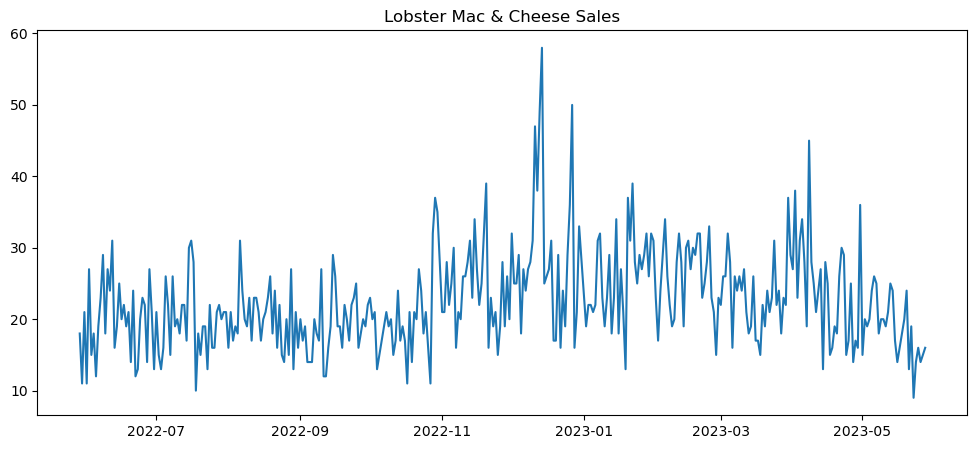

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df["ds"], df["y"])
plt.title("Lobster Mac & Cheese Sales")
plt.show()

In [12]:
# 30 derniers j pour le test

train = df.iloc[:-30]
test = df.iloc[-30:]

print(len(train))
print(len(test))

333
30


# 2. Prophet

Dans cette section, nous entraînons un modèle Prophet sur les données historiques.

## Notes

Prophet est un modèle de séries temporelles développé par Facebook (Meta).  
Contrairement à Snowflake Forecast, il est entièrement documenté, interprétable et open‑source.

---

### Principe 

Prophet repose sur une décomposition additive de la série temporelle :

**Série temporelle = Tendance + Saisonnalité + Événements spéciaux + Bruit**

Formulation :



\[
y(t) = g(t) + s(t) + h(t) + \varepsilon_t
\]



Avec :

- **g(t)** : tendance  
- **s(t)** : saisonnalité  
- **h(t)** : jours fériés / événements  
- **εₜ** : bruit résiduel

---

### Composantes du modèle

#### Tendance (g(t))
Modélise l’évolution globale de la série :
- croissance linéaire ou logistique
- détection automatique des ruptures (changepoints)

#### Saisonnalité (s(t))
Gérée via des séries de Fourier :
- saisonnalité hebdomadaire
- saisonnalité annuelle
- saisonnalités personnalisées

#### Événements / jours fériés (h(t))
Permet d’intégrer :
- jours fériés nationaux
- événements métier (soldes, campagnes, vacances)
- effets ponctuels ou récurrents
- ....

#### Bruit (εₜ)
Part de la série non expliquée par les composantes précédentes.

---

### Intérêt

- Interprétable et modulaire  
- Robuste aux données manquantes et aux valeurs aberrantes  
- Adapté aux séries business (ventes, trafic, réservations)  
- Facile à ajuster (changepoints, régularisation, holidays)


In [13]:
# Train Prophet

model = Prophet()
model.fit(train)

17:16:32 - cmdstanpy - INFO - Chain [1] start processing
17:16:33 - cmdstanpy - INFO - Chain [1] done processing


## Comprendre Prophet (approche complémentaire)

Au‑delà de sa décomposition en tendance, saisonnalité et événements, Prophet se distingue surtout par sa philosophie de modélisation.  
Il a été conçu pour répondre à des besoins opérationnels courants : séries irrégulières, données manquantes, ruptures de tendance, effets calendaires, et contraintes métier.

Prophet se positionne comme un outil :
- robuste face aux données imparfaites,
- simple à ajuster sans expertise statistique avancée,
- capable de produire des prévisions cohérentes même avec peu d’historique,
- transparent dans ses choix (changepoints, saisonnalités, effets calendaires).

Contrairement aux systèmes AutoML de prévision, Prophet laisse le contrôle total sur :
- la définition des saisonnalités,
- l’ajout d’événements spécifiques,
- la gestion des ruptures,
- la régularisation du modèle.

Cette flexibilité permet d’intégrer des connaissances métier directement dans le modèle, ce qui est rarement possible avec des solutions automatisées comme Snowflake Forecast.

In [15]:
future = test[["ds"]]

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-04-29,24.616106,19.408231,34.593697,24.616106,24.616106,2.127110,2.127110,2.127110,2.127110,2.127110,2.127110,0.0,0.0,0.0,26.743216
1,2023-04-30,24.607501,20.110822,35.366218,24.607501,24.607501,3.087574,3.087574,3.087574,3.087574,3.087574,3.087574,0.0,0.0,0.0,27.695075
2,2023-05-01,24.598897,13.474805,28.453697,24.598897,24.599265,-3.698386,-3.698386,-3.698386,-3.698386,-3.698386,-3.698386,0.0,0.0,0.0,20.900511
3,2023-05-02,24.590292,17.430665,32.179795,24.589986,24.591968,0.209506,0.209506,0.209506,0.209506,0.209506,0.209506,0.0,0.0,0.0,24.799798
4,2023-05-03,24.581687,16.247572,31.084714,24.580173,24.585080,-0.865200,-0.865200,-0.865200,-0.865200,-0.865200,-0.865200,0.0,0.0,0.0,23.716487


In [16]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='str')

## Sortie de Prophet

Après l’entraînement du modèle, Prophet renvoie un DataFrame `forecast` contenant plusieurs colonnes.  
Elles permettent d’aller bien au‑delà d’une simple valeur prédite.

### Colonnes 

- **ds** : date de la prédiction  
- **yhat** : valeur prédite  
- **yhat_lower / yhat_upper** : intervalle de confiance  
- **trend** : estimation de la tendance sous‑jacente  
- **trend_lower / trend_upper** : incertitude sur la tendance  

D’autres colonnes peuvent apparaître selon les options activées (saisonnalités, holidays, etc.).

### Intérêt 

Contrairement à un système de prévision automatisé qui renvoie uniquement une valeur (ex. Snowflake Forecast), Prophet fournit :

- une prédiction,
- un intervalle d’incertitude,
- une estimation de la tendance,
- et des composantes séparées si on les demande.

Cela permet d’interpréter la prévision, de comprendre ce qui influence le modèle et d’évaluer la stabilité du signal.

### Simplifions

Snowflake pourrait renvoyer :  
**Prévision = 42**

Prophet renvoie :  
- **yhat = 42**  
- **intervalle = [38 ; 47]**  
- **trend = 39**  

Ce niveau de détail permet une analyse plus fine et une meilleure prise de décision.


# Mean Absolute Error

## Évaluation du modèle avec le MAE

Pour mesurer la qualité des prédictions, on utilise le MAE (Mean Absolute Error).  
Il correspond à l’erreur absolue moyenne entre les valeurs réelles et les valeurs prédites.

In [17]:
mae = mean_absolute_error(
    test["y"],
    forecast["yhat"]
)

print(f"MAE: {mae:.2f}")

MAE: 6.12


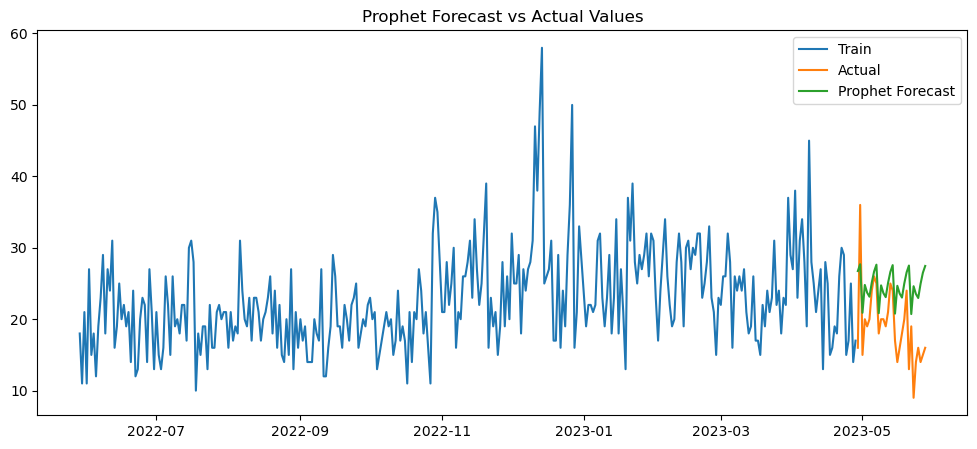

In [18]:
plt.figure(figsize=(12,5))

plt.plot(train["ds"], train["y"], label="Train")
plt.plot(test["ds"], test["y"], label="Actual")
plt.plot(test["ds"], forecast["yhat"], label="Prophet Forecast")

plt.legend()
plt.title("Prophet Forecast vs Actual Values")
plt.show()

## Analyse des résultats

Le graphique compare :
- les données d’entraînement (`Train`),
- les valeurs réelles du jeu de test (`Actual`),
- et les prévisions du modèle Prophet (`Prophet Forecast`).

On observe que les prédictions suivent globalement la tendance réelle, avec quelques écarts sur les pics de ventes.  
Pour une lecture plus complète, il est utile d’ajouter les **intervalles de confiance** fournis par Prophet.

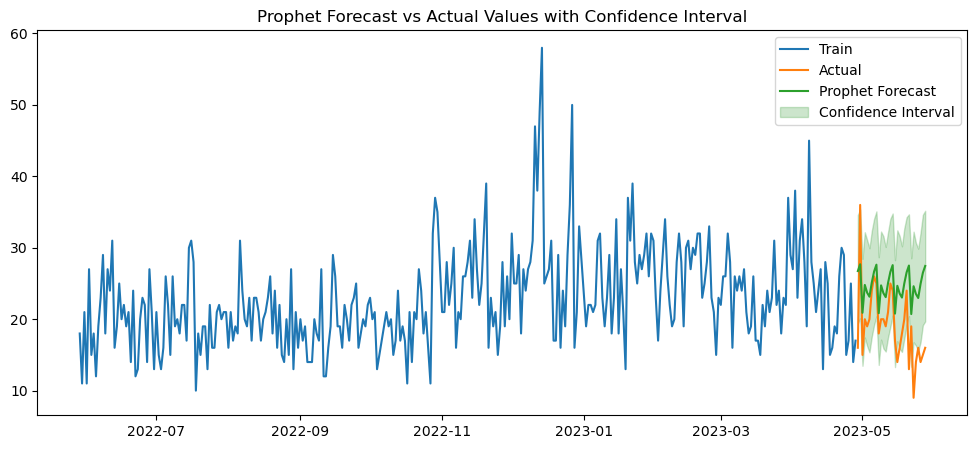

In [19]:
plt.figure(figsize=(12,5))

plt.plot(train["ds"], train["y"], label="Train")
plt.plot(test["ds"], test["y"], label="Actual")
plt.plot(test["ds"], forecast["yhat"], label="Prophet Forecast")

# Ajout des intervalles de confiance
plt.fill_between(
    test["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    color="green",
    alpha=0.2,
    label="Confidence Interval"
)

plt.legend()
plt.title("Prophet Forecast vs Actual Values with Confidence Interval")
plt.show()

## Tendances

In [20]:
full_future = model.make_future_dataframe(periods=30)

full_forecast = model.predict(full_future)

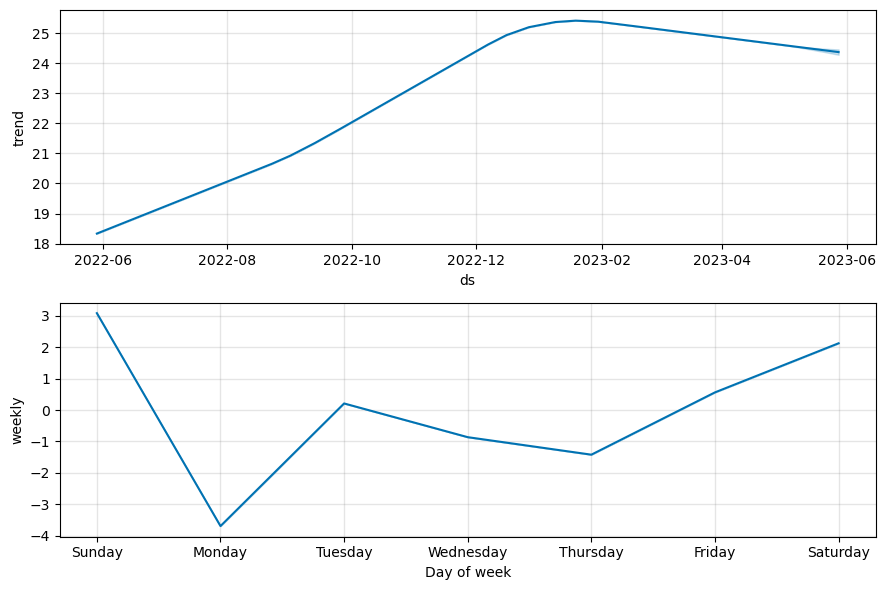

In [21]:
fig = model.plot_components(full_forecast)

Prophet expose les composantes internes du modèle, alors que Snowflake Forecast fournit principalement des prédictions et de l'importance de variables sans détailler la structure du modèle sous-jacent.

# Analyse

### Saisonnalité hebdomadaire (souvent cachée par Snowflake)

## Points forts de Prophet

- Modèle transparent et interprétable  
- Décomposition explicite de la tendance  
- Décomposition explicite de la saisonnalité  
- Intégration simple des jours fériés et événements  

Prophet permet de visualiser et comprendre les mécanismes internes du modèle, là où des solutions AutoML comme Snowflake Forecast masquent ces détails.

---

## Limites

- Nécessite une gestion manuelle du modèle (entraînement, mise à jour, validation)  
- Requiert un environnement Python configuré  
- Moins scalable que les solutions cloud entièrement gérées  

Prophet privilégie la **compréhension et le contrôle** plutôt que la **simplicité d’exécution**.  
C’est un choix idéal pour les projets où la transparence et l’interprétabilité priment sur l’automatisation.


### Observation

La prévision Snowflake converge vers un niveau moyen de demande relativement stable.

Le modèle adopte une approche prudente : il lisse fortement les variations à court terme présentes dans les données historiques, ce qui conduit à une courbe plus régulière et moins réactive aux fluctuations réelles.


# Key Learnings

Cette étude comparative entre Prophet et Snowflake Forecast met en évidence plusieurs enseignements importants, autant sur les modèles que sur la manière d’aborder la prévision en pratique.

---

## 1. Transparence vs. automatisation

Snowflake fournit une prévision simple et directe, mais masque entièrement le fonctionnement interne du modèle.  
Prophet, au contraire, expose toutes ses composantes : tendance, saisonnalités, intervalles d’incertitude, effets calendaires.

La transparence de Prophet permet une analyse fine et une meilleure compréhension des mécanismes qui influencent la demande.

---

## 2. Importance des intervalles d’incertitude

Snowflake renvoie une valeur unique.  
Prophet renvoie une prévision accompagnée d’un intervalle (`yhat_lower`, `yhat_upper`), ce qui permet d’évaluer la fiabilité de la prédiction. Les intervalles sont essentiels pour la prise de décision.

---

## 3. Lecture des résultats : tendance, saisonnalité, comportement du modèle

L’analyse des colonnes du DataFrame `forecast` montre que Prophet :
- isole la tendance,
- identifie les cycles hebdomadaires ou annuels,
- réagit aux événements si on les ajoute,
- et lisse plus ou moins selon les données.

Comprendre la décomposition permet d’expliquer les variations observées et d’ajuster le modèle en fonction du métier.

---

## 4. Différences de comportement entre les modèles

Snowflake tend à converger vers une moyenne stable et lisse fortement les fluctuations.  
Prophet, lui, suit davantage les variations locales et expose clairement les zones d’incertitude.
Les modèles automatisés privilégient la stabilité. Prophet privilégie la fidélité au signal et la lisibilité analytique.

---


## 5. Contraintes pratiques

Prophet nécessite :
- un environnement Python,
- une gestion manuelle du modèle,
- une mise à jour régulière.

Snowflake, lui, délègue tout au cloud.

Le choix dépend du contexte :  
transparence et contrôle (Prophet) vs simplicité et scalabilité (Snowflake).

---

## Synthèse

Cette exploration montre que Prophet n’est pas seulement un outil de prévision, mais un **outil d’analyse**.  
Il permet de comprendre la structure de la demande, d’identifier les cycles, et d’évaluer l’incertitude.  
Snowflake reste pertinent pour des pipelines automatisés, mais Prophet apporte une profondeur analytique essentielle pour les décisions métier.
